In [ ]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels
import statsmodels.sandbox.stats.multicomp
import pandas as pd
from statsmodels.stats.weightstats import ztest

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from sklearn.utils import shuffle
import hashlib
from base64 import b64encode
import collections
import datetime

1. Работа с метриками: логарифмирование и удаление выбросов
2. Ранговая трансформация
3. CUPED
4. Линеаризация ratio-метрик
5. Стратификация

In [ ]:
!curl -O https://raw.githubusercontent.com/YuriyKotov/datasets/master/2019-Dec.csv.zip >> 2019-Dec.csv.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 73.7M  100 73.7M    0     0  65.0M      0  0:00:01  0:00:01 --:--:-- 65.1M


In [ ]:
df = pd.read_csv('2019-Dec.csv.zip')

In [ ]:
#df = pd.read_csv('2019-dec.csv')

In [ ]:
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-12-01 00:00:00 UTC,remove_from_cart,5712790,1487580005268456287,NaN,f.o.x,6.27,576802932,51d85cb0-897f-48d2-918b-ad63965c12dc
1,2019-12-01 00:00:00 UTC,view,5764655,1487580005411062629,NaN,cnd,29.05,412120092,8adff31e-2051-4894-9758-224bfa8aec18
2,2019-12-01 00:00:02 UTC,cart,4958,1487580009471148064,NaN,runail,1.19,494077766,c99a50e8-2fac-4c4d-89ec-41c05f114554
3,2019-12-01 00:00:05 UTC,view,5848413,1487580007675986893,NaN,freedecor,0.79,348405118,722ffea5-73c0-4924-8e8f-371ff8031af4
4,2019-12-01 00:00:07 UTC,view,5824148,1487580005511725929,NaN,NaN,5.56,576005683,28172809-7e4a-45ce-bab0-5efa90117cd5


In [ ]:
shop_metrics_new = pd.read_csv('shop_df_metrics_dec.csv').drop(columns='Unnamed: 0')
shop_metrics_old = pd.read_csv('shop_df_metrics_sept.csv').drop(columns='Unnamed: 0')
shop_users_info = pd.read_csv('shop_df_users.csv').drop(columns='Unnamed: 0')

In [ ]:
def salt_generator(salt=None):
    import os
    from base64 import b64encode # кодирует байтоподобный объект с помощью Base64 и возвращает закодированную байтовую строку.
    salt = os.urandom(8)

    return b64encode(salt).decode('ascii')

# '''os.urandom() method is used to generate a string of size random bytes suitable for cryptographic use
#    or we can say this method generates a string containing random characters.'''
# https://www.geeksforgeeks.org/python-os-urandom-method/

In [ ]:

def groups_splitter(df, user_salt=None):

    if user_salt == None:
        salt = salt_generator()
    else:
        salt = user_salt

    df['hash'] = ((df['user_id'].astype(str)) + '#' + salt).apply(lambda x: hashlib.sha256(x.encode('utf-8')).hexdigest())

    df['group'] = ((df['hash'].str.slice(start=-6).apply(int, base=16) % 2).map(lambda x: 'A' if x == 0 else 'B'))

    return df[['user_id', 'group']].drop_duplicates()

# Работаем с агрегированным датафреймом

Датафрейм создан на базе https://www.kaggle.com/datasets/mkechinov/ecommerce-events-history-in-electronics-store - данные по действиям пользователей в онлайн-магазине электроники

In [ ]:
shop_metrics_new = pd.read_csv('shop_df_metrics_dec.csv').drop(columns='Unnamed: 0')
shop_metrics_old = pd.read_csv('shop_df_metrics_sept.csv').drop(columns='Unnamed: 0')
shop_users_info = pd.read_csv('shop_df_users.csv').drop(columns='Unnamed: 0')

In [ ]:
shop_users_info.dtypes

,0
user_id,int64
user_age,int64
user_sex,object


In [ ]:
shop_metrics_new.head(5)

,user_id,group,is_viewed,products_viewed_cnt,price_sum,is_cart_added,is_purchased,cart_added_cnt,purchased_cnt
0,1515915625353230683,A,1,1,339.79,0.0,0.0,0,0
1,1515915625353234047,A,1,9,861.86,0.0,0.0,0,0
2,1515915625353236157,A,1,4,179.60,0.0,0.0,0,0
3,1515915625353294441,B,1,28,4283.04,0.0,0.0,0,0
4,1515915625353386199,B,1,1,20.98,0.0,0.0,0,0


In [ ]:
shop_metrics_old.head(5)

,user_id,group,is_viewed,products_viewed_cnt,price_sum,is_cart_added,is_purchased,cart_added_cnt,purchased_cnt
0,1515915625353226922,B,1,1,76.48,0.0,0.0,0,0
1,1515915625353230067,A,1,1,28.98,0.0,0.0,0,0
2,1515915625353230683,A,1,10,592.21,0.0,0.0,0,0
3,1515915625353230922,A,1,1,274.40,0.0,0.0,0,0
4,1515915625353234047,A,1,14,1857.94,0.0,0.0,0,0


Метрики:
   - is_viewed - айтем товара просмотрен
   - products_viewed_cnt - количество уникальных просмотренных айтемов
   - price_sum - суммарная цена товаров
   - is_cart_added - товар добавлен в корзину
   - is_purchased - товар куплен
   - cart_added_cnt - количество товаров, добавленных в корзину
   - purchased_cnt - количество купленных товаров

<Axes: xlabel='cart_added_cnt', ylabel='Count'>

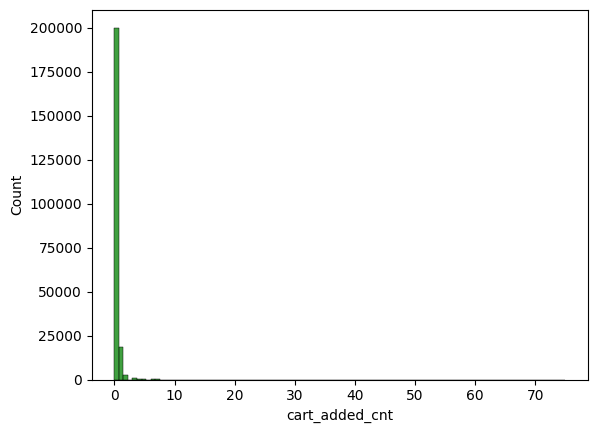

In [ ]:
sns.histplot(data=shop_metrics_new, x='cart_added_cnt', bins=100, color='green')

<Axes: xlabel='purchased_cnt', ylabel='Count'>

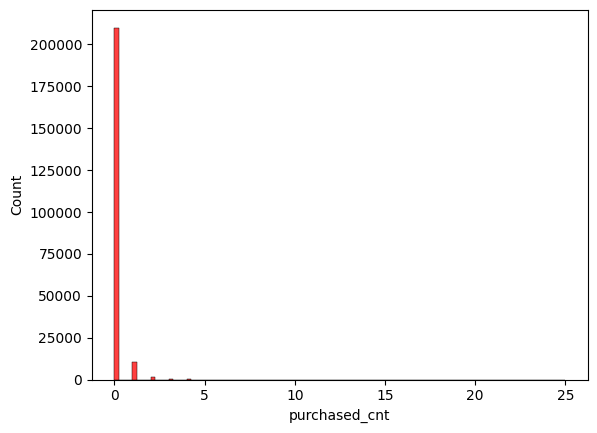

In [ ]:
sns.histplot(data=shop_metrics_new, x='purchased_cnt', bins=100, color='red')

# Посмотрим на вектор метрики purchased_cnt

In [ ]:
shop_metrics_new.groupby('group')['purchased_cnt'].describe()

,count,mean,std,min,25%,50%,75%,max
group,,,,,,,,
A,111321.0,0.068576,0.340553,0.0,0.0,0.0,0.0,25.0
B,111200.0,0.069281,0.348589,0.0,0.0,0.0,0.0,21.0


In [ ]:
np.percentile(shop_metrics_new['purchased_cnt'], 99.9)

np.float64(3.0)

In [ ]:
shop_metrics_new[shop_metrics_new['purchased_cnt'] > 3].count()

,0
user_id,207
group,207
is_viewed,207
products_viewed_cnt,207
price_sum,207
is_cart_added,207
is_purchased,207
cart_added_cnt,207
purchased_cnt,207


# Прологарифмируем

In [ ]:
shop_metrics_new['purchased_cnt_ln'] = np.log(shop_metrics_new['purchased_cnt'] + 1)

<Axes: xlabel='purchased_cnt_ln', ylabel='Count'>

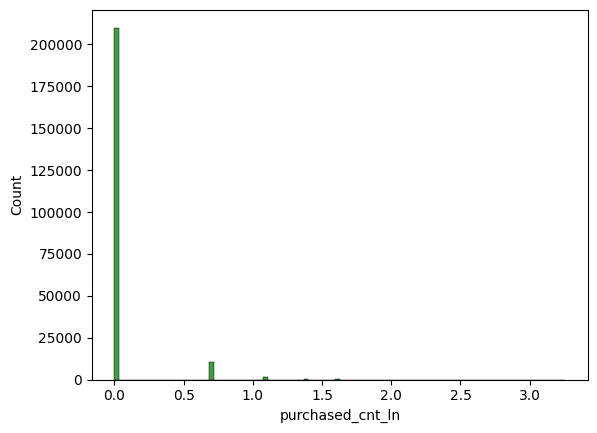

In [ ]:
sns.histplot(data=shop_metrics_new, x='purchased_cnt_ln', bins=100, color='green')

Проверим мощность и корректность t-критерия

In [ ]:
shop = shop_metrics_new.drop(columns=['group'])

In [ ]:
shop['purchased_cnt'].std()

0.3445916161029629

100%|██████████| 100/100 [01:29<00:00,  1.12it/s]


0.06465796855183144
 power: 47.0% , correctness: 93.0%


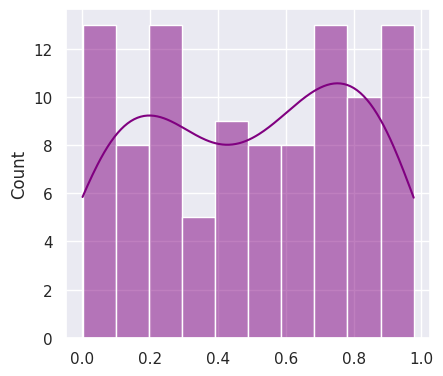

In [ ]:
# мощность и корректность t-test для исходной метрики

correctness = []
power = []

for i in tqdm(range(100)):

    new_group = groups_splitter(shop.copy(), user_salt=salt_generator())
    new_df = pd.merge(shop, new_group, how="left", on=['user_id']).drop_duplicates()

    vec_a = new_df[(new_df['group'] == 'A')]['purchased_cnt']
    vec_b = new_df[(new_df['group'] == 'B')]['purchased_cnt']
    vec_b_effect = vec_b + stats.norm.rvs(loc=vec_b.mean() * 0.05, scale=0.35, size=len(vec_b))
    p_cor, p_power = stats.ttest_ind(vec_a, vec_b)[1], stats.ttest_ind(vec_a, vec_b_effect)[1]
    correctness.append(p_cor)
    power.append(p_power)

correctness = np.array(correctness)
sns.set(rc={'figure.figsize':(4.7,4.27)})
sns.histplot(data=correctness, bins=10, color='purple', kde=True)

power = np.array(power)
print((vec_b_effect.mean() - vec_a.mean())/vec_a.mean())
print(f' power: {(power[power < 0.05].shape[0] / power.shape[0]) * 100}% , correctness: {(1 - (correctness[correctness < 0.05].shape[0] / correctness.shape[0])) * 100}%')

Для этого примера будем накладывать эффект домножением на константу, потому что нормальное распределение нам не подходит из-за появления отрицательных значений

При их логарифмировании возникнет ошибка RuntimeWarning: invalid value encountered in log в использовании функции np.log

100%|██████████| 100/100 [01:28<00:00,  1.13it/s]


 power: 61.0% , correctness: 97.0%


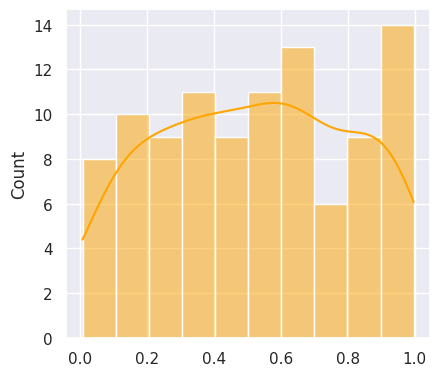

In [ ]:
correctness = []
power = []

for i in tqdm(range(100)): # 100 итераций - мало, так не делаем, пример иллюстративный

    new_group = groups_splitter(shop.copy(), user_salt=salt_generator())
    new_df = pd.merge(shop, new_group, how="left", on=['user_id']).drop_duplicates()

    vec_a = new_df[(new_df['group'] == 'A')]['purchased_cnt']
    vec_b = new_df[(new_df['group'] == 'B')]['purchased_cnt']
    vec_b_effect = vec_b * 1.05
    p_cor, p_power = stats.ttest_ind(vec_a, vec_b)[1], stats.ttest_ind(vec_a, vec_b_effect)[1]
    correctness.append(p_cor)
    power.append(p_power)

correctness = np.array(correctness)
sns.set(rc={'figure.figsize':(4.7,4.27)})
sns.histplot(data=correctness, bins=10, color='orange', kde=True)

power = np.array(power)
print(f' power: {(power[power < 0.05].shape[0] / power.shape[0]) * 100}% , correctness: {(1 - (correctness[correctness < 0.05].shape[0] / correctness.shape[0])) * 100}%')

А теперь проверим на прологарифмированной метрике

100%|██████████| 100/100 [01:59<00:00,  1.20s/it]


 power: 35.0% , correctness: 96.0%


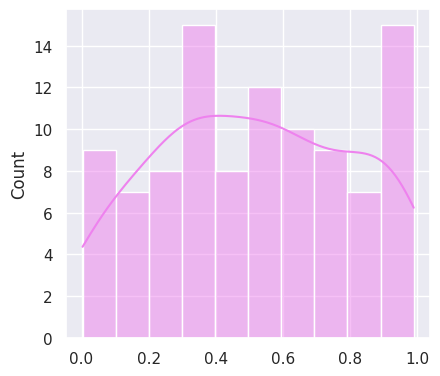

In [ ]:
# мощность и корректность

correctness = []
power = []

for i in tqdm(range(100)):

    new_group = groups_splitter(shop.copy(), user_salt=salt_generator())
    new_df = pd.merge(shop, new_group, how="left", on=['user_id']).drop_duplicates()

    vec_a = new_df[(new_df['group'] == 'A')]['purchased_cnt']
    vec_b = new_df[(new_df['group'] == 'B')]['purchased_cnt']
    vec_b_effect = vec_b * 1.05

    vec_a_ln = np.log(vec_a + 1)
    vec_b_ln = np.log(vec_b + 1)
    vec_b_effect_ln = np.log(vec_b_effect + 1) # сначала добавили эффект, а потом логарифмируем!

    p_cor, p_power = stats.ttest_ind(vec_a_ln, vec_b_ln)[1], stats.ttest_ind(vec_a_ln, vec_b_effect_ln)[1]
    correctness.append(p_cor)
    power.append(p_power)

correctness = np.array(correctness)
sns.set(rc={'figure.figsize':(4.7,4.27)})
sns.histplot(data=correctness, bins=10, color='violet', kde=True)

power = np.array(power)

print(f' power: {(power[power < 0.05].shape[0] / power.shape[0]) * 100}% , correctness: {(1 - (correctness[correctness < 0.05].shape[0] / correctness.shape[0])) * 100}%')

Вывод: мощность упала + стало сложно трактовать результаты с точки зрения эффекта

# Удаление выбросов

Попробуем удалить выбросы по стандартному отклонению и по 99 перцентилю:

In [ ]:
# посчитаем параметры и вычислим "край" метрики для подхода "3 стандартных отклонения"

print(f" metric mean: {shop_metrics_new['purchased_cnt'].mean()}, \
         metric std: {shop_metrics_new['purchased_cnt'].std()}, \
         metric edge: {(shop_metrics_new['purchased_cnt'].mean() + 3 * shop_metrics_new['purchased_cnt'].std())}")

 metric mean: 0.06892832586587333,          metric std: 0.3445916161029629,          metric edge: 1.102703174174762


In [ ]:
np.percentile(shop_metrics_new['purchased_cnt'], 99)

np.float64(1.0)

In [ ]:
shop_metrics_new[shop_metrics_new['purchased_cnt'] > 1].count()

,0
user_id,1826
group,1826
is_viewed,1826
products_viewed_cnt,1826
price_sum,1826
is_cart_added,1826
is_purchased,1826
cart_added_cnt,1826
purchased_cnt,1826
purchased_cnt_ln,1826


Снова проверим мощность и корректность на том же эффекте в 5%

100%|██████████| 100/100 [01:29<00:00,  1.11it/s]


 power: 100.0% , correctness: 95.0%


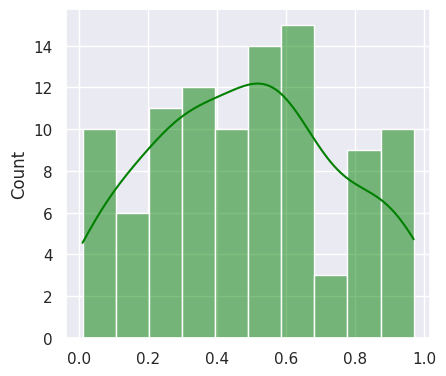

In [ ]:
# для выбросов в 3 стандартных отклонения

correctness = []
power = []

for i in tqdm(range(100)):

    new_group = groups_splitter(shop.copy(), user_salt=salt_generator())
    new_df = pd.merge(shop, new_group, how="left", on=['user_id']).drop_duplicates()

    metric_edge = new_df['purchased_cnt'].mean() + 3*new_df['purchased_cnt'].std()

    vec_a = new_df[(new_df['group'] == 'A')]['purchased_cnt']
    vec_b = new_df[(new_df['group'] == 'B')]['purchased_cnt']
    vec_b_effect = vec_b + stats.norm.rvs(loc=vec_b.mean() * 0.05, scale=0.35, size=len(vec_b))

    vec_a_reduced = vec_a[vec_a <= metric_edge]
    vec_b_reduced = vec_b[vec_b <= metric_edge]
    vec_b_effect_reduced = vec_b_effect[vec_b_effect <= metric_edge]

    p_cor, p_power = stats.ttest_ind(vec_a_reduced, vec_b_reduced)[1], stats.ttest_ind(vec_a_reduced, vec_b_effect_reduced)[1]
    correctness.append(p_cor)
    power.append(p_power)

correctness = np.array(correctness)
sns.set(rc={'figure.figsize':(4.7,4.27)})
sns.histplot(data=correctness, bins=10, color='green', kde=True)

power = np.array(power)

print(f' power: {(power[power < 0.05].shape[0] / power.shape[0]) * 100}% , correctness: {(1 - (correctness[correctness < 0.05].shape[0] / correctness.shape[0])) * 100}%')

100%|██████████| 100/100 [01:34<00:00,  1.05it/s]


 power: 100.0% , correctness: 96.0%


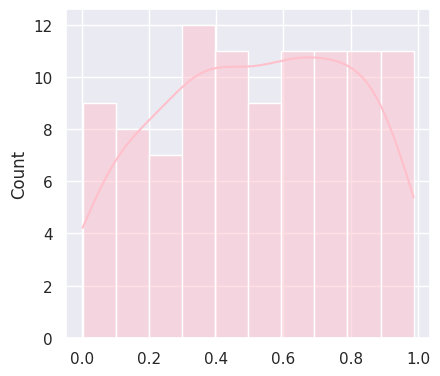

In [ ]:
# для выбросов в > 99 перцентиля

correctness = []
power = []

for i in tqdm(range(100)):

    new_group = groups_splitter(shop.copy(), user_salt=salt_generator())
    new_df = pd.merge(shop, new_group, how="left", on=['user_id']).drop_duplicates()

    metric_edge = np.percentile(new_df['purchased_cnt'], 99)

    vec_a = new_df[(new_df['group'] == 'A')]['purchased_cnt']
    vec_b = new_df[(new_df['group'] == 'B')]['purchased_cnt']
    vec_b_effect = vec_b + stats.norm.rvs(loc=vec_b.mean() * 0.05, scale=0.35, size=len(vec_b))

    vec_a_reduced = vec_a[vec_a <= metric_edge]
    vec_b_reduced = vec_b[vec_b <= metric_edge]
    vec_b_effect_reduced = vec_b_effect[vec_b_effect <= metric_edge]

    p_cor, p_power = stats.ttest_ind(vec_a_reduced, vec_b_reduced)[1], stats.ttest_ind(vec_a_reduced, vec_b_effect_reduced)[1]
    correctness.append(p_cor)
    power.append(p_power)

correctness = np.array(correctness)
sns.set(rc={'figure.figsize':(4.7,4.27)})
sns.histplot(data=correctness, bins=10, color='pink', kde=True)

power = np.array(power)

print(f' power: {(power[power < 0.05].shape[0] / power.shape[0]) * 100}% , correctness: {(1 - (correctness[correctness < 0.05].shape[0] / correctness.shape[0])) * 100}%')

А теперь посмотрим, что было бы, если эффект накладывали иначе:

100%|██████████| 100/100 [01:29<00:00,  1.12it/s]


 power: 80.0% , correctness: 97.0%


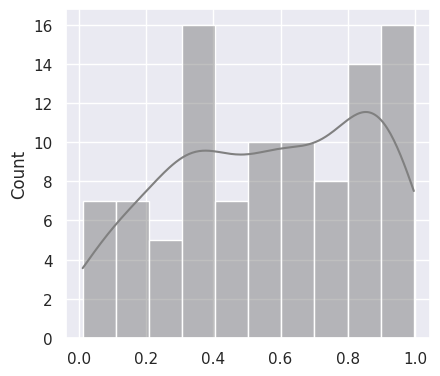

In [ ]:
# для выбросов в 3 стандартных отклонения

correctness = []
power = []

for i in tqdm(range(100)):

    new_group = groups_splitter(shop.copy(), user_salt=salt_generator())
    new_df = pd.merge(shop, new_group, how="left", on=['user_id']).drop_duplicates()

    metric_edge = new_df['purchased_cnt'].mean() + 3*new_df['purchased_cnt'].std()

    vec_a = new_df[(new_df['group'] == 'A')]['purchased_cnt']
    vec_b = new_df[(new_df['group'] == 'B')]['purchased_cnt']
    vec_b_effect = vec_b * 1.05

    vec_a_reduced = vec_a[vec_a <= metric_edge]
    vec_b_reduced = vec_b[vec_b <= metric_edge]
    vec_b_effect_reduced = vec_b_effect[vec_b_effect <= metric_edge]

    p_cor, p_power = stats.ttest_ind(vec_a_reduced, vec_b_reduced)[1], stats.ttest_ind(vec_a_reduced, vec_b_effect_reduced)[1]
    correctness.append(p_cor)
    power.append(p_power)

correctness = np.array(correctness)
sns.set(rc={'figure.figsize':(4.7,4.27)})
sns.histplot(data=correctness, bins=10, color='grey', kde=True)

power = np.array(power)

print(f' power: {(power[power < 0.05].shape[0] / power.shape[0]) * 100}% , correctness: {(1 - (correctness[correctness < 0.05].shape[0] / correctness.shape[0])) * 100}%')

100%|██████████| 100/100 [01:33<00:00,  1.07it/s]


 power: 100.0% , correctness: 94.0%


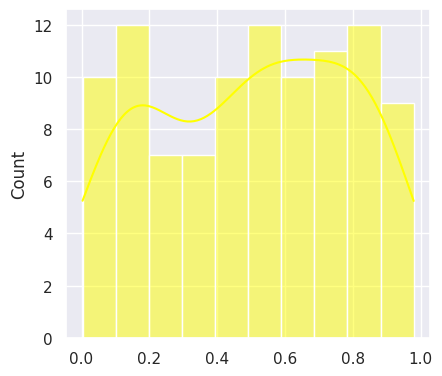

In [ ]:
# для выбросов в > 99 перцентиля

correctness = []
power = []

for i in tqdm(range(100)):

    new_group = groups_splitter(shop.copy(), user_salt=salt_generator())
    new_df = pd.merge(shop, new_group, how="left", on=['user_id']).drop_duplicates()

    metric_edge = np.percentile(new_df['purchased_cnt'], 99)

    vec_a = new_df[(new_df['group'] == 'A')]['purchased_cnt']
    vec_b = new_df[(new_df['group'] == 'B')]['purchased_cnt']
    vec_b_effect = vec_b * 1.05

    vec_a_reduced = vec_a[vec_a <= metric_edge]
    vec_b_reduced = vec_b[vec_b <= metric_edge]
    vec_b_effect_reduced = vec_b_effect[vec_b_effect <= metric_edge]

    p_cor, p_power = stats.ttest_ind(vec_a_reduced, vec_b_reduced)[1], stats.ttest_ind(vec_a_reduced, vec_b_effect_reduced)[1]
    correctness.append(p_cor)
    power.append(p_power)

correctness = np.array(correctness)
sns.set(rc={'figure.figsize':(4.7,4.27)})
sns.histplot(data=correctness, bins=10, color='yellow', kde=True)

power = np.array(power)

print(f' power: {(power[power < 0.05].shape[0] / power.shape[0]) * 100}% , correctness: {(1 - (correctness[correctness < 0.05].shape[0] / correctness.shape[0])) * 100}%')

Вывод: удаление выбросов может увеличить мощность за счет сокращения дисперсии, но если модель/фича действительно повлияла на активных юзеров с большим количеством покупок (эффект распределен неравномерно), то мы можем их удалить случайно

# Ранговая трансформация

In [ ]:
def rank_transformation(df_a, df_b, metric):
    df = pd.concat([df_a, df_b], axis = 0)
    df['rank'] = df[metric].rank()

    return df

Опробуем функцию на существующем датафрейме на той же метрике

In [ ]:
ranked = rank_transformation(shop_metrics_new[shop_metrics_new.group == 'A'],
                             shop_metrics_new[shop_metrics_new.group == 'B'], 'purchased_cnt')

In [ ]:
ranked

,user_id,group,is_viewed,products_viewed_cnt,price_sum,is_cart_added,is_purchased,cart_added_cnt,purchased_cnt,purchased_cnt_ln,rank
0,1515915625353230683,A,1,1,339.79,0.0,0.0,0,0,0.0,105026.0
1,1515915625353234047,A,1,9,861.86,0.0,0.0,0,0,0.0,105026.0
2,1515915625353236157,A,1,4,179.60,0.0,0.0,0,0,0.0,105026.0
5,1515915625353400724,A,1,2,103.33,0.0,0.0,0,0,0.0,105026.0
7,1515915625353416040,A,1,13,1861.21,0.0,0.0,0,0,0.0,105026.0
...,...,...,...,...,...,...,...,...,...,...,...
222516,1515915625611023671,B,1,1,32.22,0.0,0.0,0,0,0.0,105026.0
222517,1515915625611023730,B,1,1,219.94,0.0,0.0,0,0,0.0,105026.0
222518,1515915625611024014,B,1,1,80.03,0.0,0.0,0,0,0.0,105026.0
222519,1515915625611024020,B,1,1,64.92,0.0,0.0,0,0,0.0,105026.0


In [ ]:
ranked[ranked['purchased_cnt'] > 0]

,user_id,group,is_viewed,products_viewed_cnt,price_sum,is_cart_added,is_purchased,cart_added_cnt,purchased_cnt,purchased_cnt_ln,rank
108,1515915625367976920,A,1,4,144.83,0.0,0.0,1,1,0.693147,215373.5
142,1515915625377197718,A,1,4,630.57,0.0,0.0,3,3,1.386294,222169.5
157,1515915625382330267,A,1,3,331.89,0.0,0.0,2,2,1.098612,221360.0
184,1515915625392941295,A,1,1,20.00,0.0,0.0,1,1,0.693147,215373.5
185,1515915625393382317,A,1,8,1655.00,0.0,0.0,3,3,1.386294,222169.5
...,...,...,...,...,...,...,...,...,...,...,...
222191,1515915625610977027,B,1,1,80.56,0.0,0.0,1,1,0.693147,215373.5
222248,1515915625610986148,B,1,1,292.83,0.0,0.0,1,1,0.693147,215373.5
222277,1515915625610991774,B,1,1,298.76,0.0,0.0,1,1,0.693147,215373.5
222314,1515915625610995356,B,1,1,29.40,0.0,0.0,1,1,0.693147,215373.5


In [ ]:
print(ranked[ranked.group == 'A']['rank'].mean(),
      ranked[ranked.group == 'B']['rank'].mean(),
      ((ranked[ranked.group == 'B']['rank'].mean() - ranked[ranked.group == 'A']['rank'].mean()) /
       ranked[ranked.group == 'A']['rank'].mean()*100))

111259.8768022206 111262.12441996404 0.0020201512063729755


In [ ]:
stats.ttest_ind(ranked[ranked.group == 'A']['rank'], ranked[ranked.group == 'B']['rank'])

TtestResult(statistic=np.float64(-0.020711883610533208), pvalue=np.float64(0.9834755078743136), df=np.float64(222519.0))

Различий между группами не было => t-test не нашел разницу

Средние изменились достаточно сильно (по сравнению с исходными), разница между группами ~0.2%

Для сравнения t-test на той же метрике, но без ранговой трансформации:

In [ ]:
stats.ttest_ind(shop_metrics_new[shop_metrics_new.group == 'A']['purchased_cnt'],
                shop_metrics_new[shop_metrics_new.group == 'B']['purchased_cnt'])

TtestResult(statistic=np.float64(-0.4819416819988476), pvalue=np.float64(0.6298478488694023), df=np.float64(222519.0))

Cредние тоже практически идентичны, но разница между группами выше

In [ ]:
print(shop_metrics_new[shop_metrics_new.group == 'A']['purchased_cnt'].mean(),
      shop_metrics_new[shop_metrics_new.group == 'B']['purchased_cnt'].mean(),
     ((shop_metrics_new[shop_metrics_new.group == 'B']['purchased_cnt'].mean() - shop_metrics_new[shop_metrics_new.group == 'A']['purchased_cnt'].mean())/shop_metrics_new[shop_metrics_new.group == 'A']['purchased_cnt'].mean()*100))

0.068576459068819 0.06928057553956835 1.0267611951832336


Сравним с результатом применения критерия Манна-Уитни:

In [ ]:
stats.mannwhitneyu(shop_metrics_new[shop_metrics_new.group == 'A']['purchased_cnt'],
                   shop_metrics_new[shop_metrics_new.group == 'B']['purchased_cnt'])

MannwhitneyuResult(statistic=np.float64(6189322564.5), pvalue=np.float64(0.9834755182644684))

Проверим мощность и корректность t-test для метода ранговой трансформации

100%|██████████| 100/100 [01:57<00:00,  1.18s/it]


 power: 62.0% , correctness: 97.0%


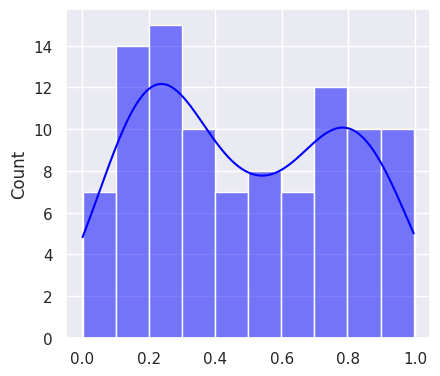

In [ ]:
# мощность и корректность для ранговой трансформации

correctness = []
power = []

for i in tqdm(range(100)):

    new_group = groups_splitter(shop.copy(), user_salt=salt_generator())
    new_df = pd.merge(shop, new_group, how="left", on=['user_id']).drop_duplicates()

    ranked_df = rank_transformation(new_df[new_df.group == 'A'], new_df[new_df.group == 'B'], 'purchased_cnt')

    vec_a = ranked_df[(ranked_df['group'] == 'A')]['rank']
    vec_b = ranked_df[(ranked_df['group'] == 'B')]['rank']

    vec_b_effect = new_df[new_df['group'] == 'B']['purchased_cnt'] * 1.05
    new_df_b = new_df[new_df.group == 'B'].drop(columns=['purchased_cnt'])
    new_df_b['purchased_cnt'] = list(vec_b_effect)

    ranked_df_effect = rank_transformation(new_df[new_df.group == 'A'], new_df_b, 'purchased_cnt')
    vec_a_power = ranked_df_effect[(ranked_df_effect['group'] == 'A')]['rank']
    vec_b_power = ranked_df_effect[(ranked_df_effect['group'] == 'B')]['rank']


    p_cor, p_power = stats.ttest_ind(vec_a, vec_b)[1], stats.ttest_ind(vec_a_power, vec_b_power)[1]
    correctness.append(p_cor)
    power.append(p_power)

correctness = np.array(correctness)
sns.set(rc={'figure.figsize':(4.7,4.27)})
sns.histplot(data=correctness, bins=10, color='blue', kde=True)

power = np.array(power)

print(f' power: {(power[power < 0.05].shape[0] / power.shape[0]) * 100}% , correctness: {(1 - (correctness[correctness < 0.05].shape[0] / correctness.shape[0])) * 100}%')

Мощность выросла, но не очень сильно (с ~50% до ~67%)

# CUPED

In [ ]:
def cuped_transform(df, metrics):

    new_columns = [str(m+'_cuped') for m in metrics]
    df[new_columns] = pd.DataFrame([[0] * len(new_columns)], index=df.index)

    df_mini = df.fillna(0)
    for m in metrics:
        covariate_column = str(m+'_covariate')
        cuped_column = str(m+'_cuped')
        mean_covariate = df_mini[covariate_column].mean()

        theta = (df_mini[m].cov(df_mini[covariate_column]))/(df_mini.loc[:,covariate_column].var())
        df_mini[cuped_column] = df_mini[m] - (df_mini[covariate_column] - mean_covariate) * theta

    df.update(df_mini)

    return df.drop_duplicates()


Возьмем исторические значения из датафрейма old

In [ ]:
shop_metrics_old.head()

,user_id,group,is_viewed,products_viewed_cnt,price_sum,is_cart_added,is_purchased,cart_added_cnt,purchased_cnt
0,1515915625353226922,B,1,1,76.48,0.0,0.0,0,0
1,1515915625353230067,A,1,1,28.98,0.0,0.0,0,0
2,1515915625353230683,A,1,10,592.21,0.0,0.0,0,0
3,1515915625353230922,A,1,1,274.40,0.0,0.0,0,0
4,1515915625353234047,A,1,14,1857.94,0.0,0.0,0,0


In [ ]:
shop_metrics_all = pd.merge(shop_metrics_new, shop_metrics_old[['user_id', 'purchased_cnt']], on=['user_id'], how='left')

In [ ]:
shop_metrics_all = shop_metrics_all\
                   .rename(columns={'purchased_cnt_x': 'purchased_cnt', 'purchased_cnt_y': 'purchased_cnt_covariate'})

In [ ]:
shop_metrics_all_cuped = cuped_transform(shop_metrics_all.copy(), ['purchased_cnt'])

/tmp/ipython-input-3236988277.py:15: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.06785952 0.06785952 0.06785952 ... 0.06785952 0.06785952 0.06785952]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.update(df_mini)


In [ ]:
shop_metrics_all_cuped.head()

,user_id,group,is_viewed,products_viewed_cnt,price_sum,is_cart_added,is_purchased,cart_added_cnt,purchased_cnt,purchased_cnt_ln,purchased_cnt_covariate,purchased_cnt_cuped
0,1515915625353230683,A,1,1,339.79,0.0,0.0,0,0,0.0,0,0.06786
1,1515915625353234047,A,1,9,861.86,0.0,0.0,0,0,0.0,0,0.06786
2,1515915625353236157,A,1,4,179.60,0.0,0.0,0,0,0.0,0,0.06786
3,1515915625353294441,B,1,28,4283.04,0.0,0.0,0,0,0.0,0,0.06786
4,1515915625353386199,B,1,1,20.98,0.0,0.0,0,0,0.0,0,0.06786


Проверим, как на измененной метрике покажет себя t-test:

In [ ]:
stats.ttest_ind(shop_metrics_all_cuped[shop_metrics_all_cuped.group == 'A']['purchased_cnt_cuped'],
                shop_metrics_all_cuped[shop_metrics_all_cuped.group == 'B']['purchased_cnt_cuped'])

TtestResult(statistic=np.float64(-1.3272760435851836), pvalue=np.float64(0.18441874726997393), df=np.float64(222519.0))

Сравним средние в измененной метрике и дисперсии:

In [ ]:
print(f'метрика_cuped A: {shop_metrics_all_cuped[shop_metrics_all_cuped.group == "A"]["purchased_cnt_cuped"].mean()}, \
        метрика_cuped B: {shop_metrics_all_cuped[shop_metrics_all_cuped.group == "B"]["purchased_cnt_cuped"].mean()}')
print(f'метрика без cuped A: {shop_metrics_all_cuped[shop_metrics_all_cuped.group == "A"]["purchased_cnt"].mean()}, \
        метрика без cuped B: {shop_metrics_all_cuped[shop_metrics_all_cuped.group == "B"]["purchased_cnt"].mean()}')

метрика_cuped A: 0.06873279002556369,         метрика_cuped B: 0.06912407447449846
метрика без cuped A: 0.068576459068819,         метрика без cuped B: 0.06928057553956835


In [ ]:
print(f'метрика_cuped A: {shop_metrics_all_cuped[shop_metrics_all_cuped.group == "A"]["purchased_cnt_cuped"].var()}, \
        метрика_cuped B: {shop_metrics_all_cuped[shop_metrics_all_cuped.group == "B"]["purchased_cnt_cuped"].var()}')
print(f'метрика без cuped A: {shop_metrics_all_cuped[shop_metrics_all_cuped.group == "A"]["purchased_cnt"].var()}, \
        метрика без cuped B: {shop_metrics_all_cuped[shop_metrics_all_cuped.group == "B"]["purchased_cnt"].var()}')

метрика_cuped A: 0.005196228304093855,         метрика_cuped B: 0.0044728677815219315
метрика без cuped A: 0.1159763502649322,         метрика без cuped B: 0.12151424424733234


Все хорошо: средние сохранились, а дисперсии сократились => понимаем, почему снизился p-value

  0%|          | 0/100 [00:00<?, ?it/s]/tmp/ipython-input-2982338431.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_df[(cuped_df['group'] == 'B')]['purchased_cnt'] = vec_b
/tmp/ipython-input-3236988277.py:15: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.06785952 0.06785952 0.06785952 ... 0.06785952 0.06785952 0.06785952]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.update(df_mini)
  1%|          | 1/100 [00:01<01:40,  1.02s/it]/tmp/ipython-input-2982338431.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See t

 power: 100.0% , correctness: 98.0%


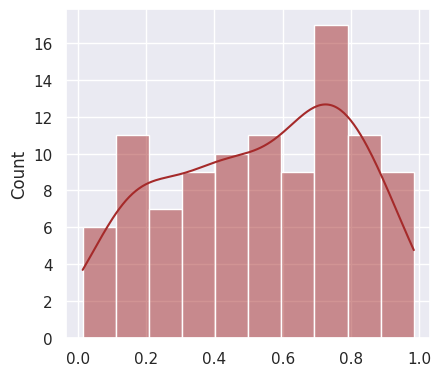

In [ ]:
# мощность и корректность для CUPED

correctness = []
power = []

for i in tqdm(range(100)):

    new_group = groups_splitter(shop.copy(), user_salt=salt_generator())
    new_df = pd.merge(shop, new_group, how="left", on=['user_id']).drop_duplicates()
    all_df = pd.merge(new_df, shop_metrics_old[['user_id', 'purchased_cnt']], on=['user_id'], how='left')
    all_df = all_df.rename(columns={'purchased_cnt_x': 'purchased_cnt', 'purchased_cnt_y': 'purchased_cnt_covariate'})
    vec_b = all_df[(cuped_df['group'] == 'B')]['purchased_cnt'] * 1.05
    all_df[(cuped_df['group'] == 'B')]['purchased_cnt'] = vec_b
    cuped_df = cuped_transform(all_df, ['purchased_cnt'])

    vec_a = cuped_df[(cuped_df['group'] == 'A')]['purchased_cnt_cuped']
    vec_b = cuped_df[(cuped_df['group'] == 'B')]['purchased_cnt_cuped']

   # vec_b_effect = vec_b * 1.05


    p_cor, p_power = stats.ttest_ind(vec_a, vec_b)[1], stats.ttest_ind(vec_a, vec_b_effect)[1]
    correctness.append(p_cor)
    power.append(p_power)

correctness = np.array(correctness)
sns.set(rc={'figure.figsize':(4.7,4.27)})
sns.histplot(data=correctness, bins=10, color='brown', kde=True)

power = np.array(power)

print(f' power: {(power[power < 0.05].shape[0] / power.shape[0]) * 100}% , correctness: {(1 - (correctness[correctness < 0.05].shape[0] / correctness.shape[0])) * 100}%')

# Линеаризация ratio-метрик

In [ ]:
def linearization(X, Y):

    import numpy as np

    X_mean = np.mean(X)
    Y_mean = np.mean(Y)
    X_Y = X_mean/Y_mean
    z = [ X_Y + (X[i] - X_Y*Y[i])/Y_mean for i in range(len(X))]
    return z


ctr_u = sum(cliked_u) / sum(views_u), CTR = mean(ctr_u),   lin_u = sum(cliked_u) - K_control * sum(views_u), K_control = mean(CTR_control)

In [ ]:
def lin_results(df, metric_numerator, metric_denominator):

    new_a = linearization(df[df['group']=='A'][metric_numerator].values, df[df['group']=='A'][metric_denominator].values)
    new_b = linearization(df[df['group']=='B'][metric_numerator].values, df[df['group']=='B'][metric_denominator].values)

    return metric_numerator, metric_denominator, scipy.stats.ttest_ind(new_a, new_b)

Создадим ratio-метрику:

In [ ]:
shop_metrics_new['ratio_metric'] = shop_metrics_new['cart_added_cnt'] / shop_metrics_new['products_viewed_cnt']

In [ ]:
shop_metrics_new.head()

,user_id,group,is_viewed,products_viewed_cnt,price_sum,is_cart_added,is_purchased,cart_added_cnt,purchased_cnt,purchased_cnt_ln,ratio_metric
0,1515915625353230683,A,1,1,339.79,0.0,0.0,0,0,0.0,0.0
1,1515915625353234047,A,1,9,861.86,0.0,0.0,0,0,0.0,0.0
2,1515915625353236157,A,1,4,179.60,0.0,0.0,0,0,0.0,0.0
3,1515915625353294441,B,1,28,4283.04,0.0,0.0,0,0,0.0,0.0
4,1515915625353386199,B,1,1,20.98,0.0,0.0,0,0,0.0,0.0


In [ ]:
K_control = shop_metrics_new[shop_metrics_new['group'] == 'B']['ratio_metric'].mean()

In [ ]:
K_control

np.float64(0.07284315283324067)

In [ ]:
shop_metrics_new['lin_metric'] = shop_metrics_new['cart_added_cnt'] - K_control * shop_metrics_new['products_viewed_cnt']

In [ ]:
lin_results(shop_metrics_new, 'cart_added_cnt', 'products_viewed_cnt')

('cart_added_cnt',
 'products_viewed_cnt',
 TtestResult(statistic=np.float64(-1.2024848919197622), pvalue=np.float64(0.2291769956760565), df=np.float64(222519.0)))

Сравним с результатами, полученными "в лоб"

In [ ]:
stats.ttest_ind(shop_metrics_new[shop_metrics_new.group == 'A']['ratio_metric'],
                shop_metrics_new[shop_metrics_new.group == 'B']['ratio_metric'])

TtestResult(statistic=np.float64(-1.1548393785270104), pvalue=np.float64(0.2481574481581119), df=np.float64(222519.0))

# Постстратификация

In [ ]:
shop_users_info.head()

,user_id,user_age,user_sex
0,1515915625519388267,41,f
1,1515915625519380411,84,m
2,1515915625513238515,41,m
3,1515915625519014356,25,m
4,1515915625510743344,42,m


In [ ]:
shop_w_features = pd.merge(shop_metrics_new, shop_users_info, on=['user_id'], how='left')

In [ ]:
shop_w_features['age_group'] = shop_w_features['user_age'].mask(shop_w_features['user_age'] < 60, '60minus') \
                               .mask(shop_w_features['user_age'] >= 60, '60plus')

In [ ]:
shop_w_features.groupby('group')['age_group'].value_counts()

group  age_group
A      60minus      70034
       60plus       41287
B      60minus      69735
       60plus       41465
Name: count, dtype: int64

Распределение и так довольно равномерное по группам

Вспомним классический результат

In [ ]:
stats.ttest_ind(shop_w_features[shop_w_features.group == 'A']['purchased_cnt'],
                shop_w_features[shop_w_features.group == 'B']['purchased_cnt'])

TtestResult(statistic=np.float64(-0.4819416819988476), pvalue=np.float64(0.6298478488694023), df=np.float64(222519.0))

In [ ]:
(shop_w_features[shop_w_features.group == 'B']['purchased_cnt'].mean() - shop_w_features[shop_w_features.group == 'A']['purchased_cnt'].mean()) \
        /shop_w_features[shop_w_features.group == 'A']['purchased_cnt'].mean() * 100

np.float64(1.0267611951832336)

In [ ]:
print(shop_w_features[shop_w_features.group == 'A']['purchased_cnt'].std(),
      shop_w_features[shop_w_features.group == 'B']['purchased_cnt'].std())

0.3405530065422007 0.34858893305343525


Теперь применим стратификацию и посмотрим, что получится

In [ ]:
N = shop_w_features['user_id'].nunique()

strats_weights = {}

for i in range(0, shop_w_features['age_group'].nunique()):
    key = shop_w_features['age_group'].value_counts().index[i]
    strats_weights[key] = shop_w_features['age_group'].value_counts()[i] / N

mean_a = shop_w_features[(shop_w_features.group == 'A') & (shop_w_features['age_group'] == '60minus')]['purchased_cnt'].mean() * strats_weights['60minus']\
        + shop_w_features[(shop_w_features.group == 'A') & (shop_w_features['age_group'] == '60plus')]['purchased_cnt'].mean() * strats_weights['60plus']\

mean_b = shop_w_features[(shop_w_features.group == 'B') & (shop_w_features['age_group'] == '60minus')]['purchased_cnt'].mean() * strats_weights['60minus']\
        + shop_w_features[(shop_w_features.group == 'B') & (shop_w_features['age_group'] == '60plus')]['purchased_cnt'].mean() * strats_weights['60plus']

std_a = (shop_w_features[(shop_w_features.group == 'A') & (shop_w_features['age_group'] == '60minus')]['purchased_cnt'].std()**2 * strats_weights['60minus']\
        + shop_w_features[(shop_w_features.group == 'A') & (shop_w_features['age_group'] == '60plus')]['purchased_cnt'].std()**2 * strats_weights['60plus']) # / N
std_b = (shop_w_features[(shop_w_features.group == 'B') & (shop_w_features['age_group'] == '60minus')]['purchased_cnt'].std()**2 * strats_weights['60minus']\
        + shop_w_features[(shop_w_features.group == 'B') & (shop_w_features['age_group'] == '60plus')]['purchased_cnt'].std()**2 * strats_weights['60plus']) # / N

n_a = len(shop_w_features[shop_w_features.group == 'A'])
n_b = len(shop_w_features[shop_w_features.group == 'B'])

print(f'effect: {(mean_b - mean_a)/mean_a*100}, std_a: {std_a}, std_b: {std_b}')

stats.ttest_ind_from_stats(mean_a, std_a, n_a, mean_b, std_b, n_b)

/tmp/ipython-input-3253372824.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  strats_weights[key] = shop_w_features['age_group'].value_counts()[i] / N
/tmp/ipython-input-3253372824.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  strats_weights[key] = shop_w_features['age_group'].value_counts()[i] / N


effect: 1.029043278738222, std_a: 0.1159690992820945, std_b: 0.12150240209269882


Ttest_indResult(statistic=np.float64(-1.4013843118885034), pvalue=np.float64(0.16110057571031125))

In [ ]:
strats_weights

{'60minus': np.float64(0.6281159980406343),
 '60plus': np.float64(0.3718840019593656)}